# Terminal Distribution Generator

### Introduction
This notebook produces risk neutral distributions of QQQ, extracted from QQQ options with the Breeden-Litzenberger formula.

A distribution will be found for every expiry date of every snapshot date given in the options data (i.e. multiple DTEs for each snapshot date) provided that there is sufficient data in the first place. 

### Breeden-Litzenberger formula
A formula that describes the implied or risk-neutral (under the $\mathbb{Q}$-measure) probability density distribution$$ f_{S_T}^\mathbb{Q} (s) $$ which describes the density of the terminal spot price $S_T$ at maturity $T$.

# Contents

### 1. **Importing relevant libraries and data**

* Options data from [EODHD](https://eodhd.com/)

* Spot data from [Yahoo Finance](https://sg.finance.yahoo.com/quote/QQQ/)

* Rate data from [Federal Reserve Bank](https://fred.stlouisfed.org/series/DFF)

* Quarterly dividends data from [Macro Trends](https://www.macrotrends.net/stocks/charts/QQQ/invesco-qqq/dividend-yield-history)

### 2. **Helper functions**

* ```get_rate``` returns the FED rate for a given date

* ```filter``` returns filtered options data

* ```get_dte``` returns DTE in days 

* ```get_spot_price``` returns the spot price for a given date

* ```get_call_price``` and ```get_put_price``` return the price of a call and put respectively for a given strike

* ```mono_convex``` checks a grid of $(K, C)$ pairs for monotonocity and convexity, and returns a Boolean depending on the outcome of the tests

### 3. **Main Procedure functions:**

* ```build_grid``` returns a grid of $(K, C)$ pairs

* ```smooth``` returns a smoothened function $C(K)$ given a grid

* ```bl``` returns a tuple of (strike, RND) pairs base on Breeden-Litzenberger 

### 4. **Executing main procedure**

The current content here resembles a test and can be modified to output the RND for a certain DTE or other metadata if required.  

# 1. Importing Data

In [177]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import random
from scipy.interpolate import PchipInterpolator 
from scipy.signal import savgol_filter

OPTIONS = pd.read_csv("../data/qqq_options_100.csv") 

SPOTS = pd.read_csv("../data/qqq_daily_ohlcv_2024_2026.csv", 
                    skiprows=3,  # Skip the 3 header rows
                    index_col=0,  # date becomes index
                    names=['date', 'close', 'high', 'low', 'open', 'volume']
)
SPOTS.index.name = 'date' # ensure index name is still date

RATES = pd.read_csv('../data/DFF.csv',
                    index_col=0 # First column (date) becomes index
)
RATES.index.name = 'date' # use date as index
RATES.rename(columns = {'Rate': 'rate'}, inplace = True) # rename Rate to rate

DIVIDENDS = {
    '2023-12-27': 0.061, #Q4 2023
    '2024-03-18': 0.060, #Q1 2024
    '2024-06-24': 0.061, # Q2 2024
    '2024-09-23': 0.063, # Q3 2024
    '2024-12-23': 0.054, # Q4 2024
    '2025-03-24': 0.061, # Q1 2025
    '2025-06-23': 0.053, # Q2 2025
    '2025-09-22': 0.047, # Q3 2025
    '2025-12-22': 0.045, # Q4 2025
    '2026-03-23': 0.048, # Q1 2026
    '2026-05-29': 0.038, # Q2 2026
}

# 2. Helper Functions

## FED Rate

Returns the FED rate

In [178]:
def get_rate(rates, date):
    '''Returns FED rate for a given date'''
    for idx, row in rates.iterrows():
        if idx == date:
            return row['rate']
    return None

## Filtering options data for a given snapshot and expiration
Returns filtered options data, for a given snapshot date and expiration date, and None if the data is empty after filtering

In [179]:
def filter(options, snap, exp):
    ''' 
    Returns filtered options data
    None if data is empty
    '''
    data = options[(options['snapshot_date'] == snap) &
                   (options['exp_date'] == exp)
                   ]
    return None if data.empty else data

## DTE in days
Returns DTE in days for a given snapshot date and expiration date

In [180]:
def get_dte(snap, exp):
    '''Returns DTE in days'''
    snap = pd.to_datetime(snap)
    exp = pd.to_datetime(exp)
    dte = (exp - snap).days
    return dte

## Spot prices

Returns the spot price for a given date, and None if the date cannot be found in the spot data

In [181]:
def get_spot_price(spots, snap):
    '''
    Returns spot price
    None if price not found
    '''
    if snap not in spots.index:
        return None
    else:
        return spots.loc[snap, 'close']

## Call and Put prices
Returns the price of either a call or put based on options data that is **already filtered** using ```filter```, for a given snapshot date and expiration date.

If the filtered options data is empty, or at least one of bid and ask data is invalid, returns None.

In [182]:
def get_call_price(options, k):
    '''
    Returns call price
    None if filtered options data is empty
    None if either bid or ask is invalid
    '''
    data = options[(options['type'] == 'call') &
                   (options['strike'] == k)
                   ]
    if data.empty: # if no calls are found
        return None
    row = data.iloc[0]
    bid = row['bid']
    ask = row['ask']
    if pd.isna(bid) or pd.isna(ask) or bid <= 0 or ask <= 0 or bid >= ask: # invalid bid ask values
        return None
    return (row['bid'] + row['ask']) / 2
    
def get_put_price(options, k):
    '''
    Returns put price
    None if filtered options data is empty
    None if either bid or ask is invalid
    '''
    data = options[(options['type'] == 'put') &
                   (options['strike'] == k)
                   ]
    if data.empty: # if no puts are found
        return None
    row = data.iloc[0]
    bid = row['bid']
    ask = row['ask']
    if pd.isna(bid) or pd.isna(ask) or bid <= 0 or ask <= 0 or bid >= ask: # invalid bid ask values
        return None
    return (row['bid'] + row['ask']) / 2
    

## Quarterly Dividend Yield
Returns the appropriate dividend yield for a given date

In [183]:
def get_dividend_yield(snap, exp, dividend_dict):
    """
    Calculate annualized dividend yield for QQQ between snapshot and expiration dates.
    
    Quarterly-based approach:
    - Finds all dividend ex-dates between snapshot and expiration
    - Sums actual dividend amounts to be paid
    - Computes annualized yield accounting for exact payment timing
    
    Methodology:
        - Paid yield = (Σ dividends paid) / (spot price)
        - Annualized = Paid yield * (365 / days_to_expiration)
        - This accounts for the exact number and timing of dividend payments
    
    Example:
        If snapshot='2024-01-15', expiration='2024-06-15'
        And QQQ pays $0.060 on 2024-03-18 (within period):
        - 1 dividend falls within period
        - 6-month implied yield ≈ 0.060/420 ≈ 0.143% for 6 months
        - Annualized ≈ 0.143% × (365/152) ≈ 0.34% ≈ 0.0034
    """
    
    snap_dt = pd.to_datetime(snap)
    exp_dt = pd.to_datetime(exp)
    dte = (exp_dt - snap_dt).days
    
    if dte <= 0:
        return 0.0  # Invalid date range
    
    # Find all dividends paid between snapshot (inclusive) and expiration (exclusive)
    # We use "ex-dividend date" logic: if ex-date is between snap and exp, dividend will be paid
    dividends_in_period = []
    
    for ex_date_str, dividend_amount in dividend_dict.items():
        ex_dt = pd.to_datetime(ex_date_str)
        
        # Include dividend if ex-date falls within period
        # (shareholders own shares on ex-date, receive dividend)
        if snap_dt <= ex_dt < exp_dt:
            dividends_in_period.append({
                'ex_date': ex_dt,
                'amount': dividend_amount,
                'days_to_payment': (ex_dt - snap_dt).days
            })
    
    if not dividends_in_period:
        # No dividends in period: use historical average
        # Calculate average quarterly dividend from historical data
        if len(dividend_dict) > 0:
            avg_dividend = np.mean(list(dividend_dict.values()))
            # Estimate how many quarters in this period
            quarters = max(1, dte / 91.25)  # 91.25 = avg days per quarter
            total_expected = avg_dividend * quarters
        else:
            return 0.0
    else:
        # Sum all dividends that will be paid in this period
        total_expected = sum(div['amount'] for div in dividends_in_period)
    
    # Get approximate spot price for yield calculation
    # Use the SPOTS dataframe (available in notebook context)
    if snap in SPOTS.index:
        spot_price = SPOTS.loc[snap, 'close']
    else:
        # If exact date not available, use last available before snap
        available_dates = SPOTS.index[SPOTS.index <= snap]
        if len(available_dates) > 0:
            spot_price = SPOTS.loc[available_dates[-1], 'close']
        else:
            return 0.0  # Can't calculate without spot price
    
    # Calculate yield for the period, then annualize
    period_yield = total_expected / spot_price
    annualized_yield = period_yield * (365 / dte)
    
    # Sanity checks
    if annualized_yield < 0 or annualized_yield > 0.30:  # Yield > 30% is unrealistic
        # Fall back to simple average if result seems wrong
        avg_div = np.mean(list(dividend_dict.values()))
        annualized_yield = (avg_div / spot_price) * 4  # Assume 4 quarters/year
    
    return max(0.0, annualized_yield)  # Ensure non-negative

## Monotonocity and Convexity checker
For a given grid of $(K, C)$ pairs, test whether monotonocity and convexity are maintained by temporarily adding the pair to the existing grid before removing it again.

Return True it passes all the tests, False otherwise.

### Additional Notes on monotonocity and convexity
Convexity which is the second derivative should monotonically decrease. If the call surface violates this, convexity becomes noisy, have sign reversals, and therefore create nonsensical RND graphs. 

In [184]:
def mono_convex(grid, k, c):
    '''
    Returns True if all tests are passed, False otherwise.
    '''
    grid.append((k, c)) # add current pair
    grid.sort(key = lambda pair: pair[0]) # sort by strike

    # position of new pair post sort
    curr_idx = next(i for i, pair in enumerate(grid) if pair == (k, c))
    
    def get_k(idx):
        return grid[idx][0]
    
    def get_c(idx):
        return grid[idx][1]
    
    if len(grid) >= 2:
        if get_c(curr_idx) >= get_c(curr_idx - 1):
            grid.remove((k, c)) # remove most recent pair
            return False
    
    if len(grid) >= 3:
        # spreads
        dc1 = get_c(curr_idx-2) - get_c(curr_idx-1)
        dc2 = get_c(curr_idx-1) - get_c(curr_idx)
        dk1 = get_k(curr_idx-1) - get_k(curr_idx-2)
        dk2 = get_k(curr_idx) - get_k(curr_idx-1)

        # normalised spreads
        norm_spread1 = dc1 / dk1 # slope of first segment
        norm_spread2 = dc2 / dk2 # slope of second segment

        # check convexity with some tolerance, slopes should decrease smoothly
        if norm_spread2 > norm_spread1 * 1.1: 
            grid.remove((k, c)) # remove most recent pair
            return False
        
    grid.remove((k, c)) # remove most recent pair
    return True

# 3. Main Procedure Functions

## Build $(K, C)$ grid
Returns a tuple of $(K, C)$ pairs which form the grid  for a given snapshot date and expiration date

1. Filter options data with ```filter```

2. Extract all unique strikes, then loop through to add relevant pairs to the grid

    * Skip strikes with no existing options, spot, or rate data

    * Prioritise OTM options as they are more liquid and have more information (higher volume, tighter bid-ask spreads, more sensitive to small changes in probability in tails hence giving better information on RNDs)

    * If $K > S$, use $C$. If $K \leq S$, use $P$. In the case where only one is available, use put-call parity to find the other if necessary. This is the strategy presented in the paper by Ait-Shahalia and Andrew Lo (1998).

    * Put call parity is given by $$ C_t = P_t + e^{-r(T-t)}(F_t - K) $$
    where the forward is given by $$F_t = S_t e^{(r-q)(T-t)}$$ and $q$ is the dividend, calculated on a quarterly basis with ```get_dividend_yield```

    * Ensure no-arbitrage holds

3. Add relevant pairs to the grid

4. Remove high-curvature outliers that may create noise in the second derivative later on such as multi-peak RNDs. This was the case before this additional step was added.
    * Smoothen the grid using the Savitsky-Golay filter. This smooths data points by fitting successive sub-sets of adjacent data points with a low-degree polynomial (for simplicity and to prevent overfitting) using the method of linear least squares. Primary advantage lies in its ability to smooth data while preserving original features.
  
    * Compares original points with those of the smoothened curve. Those with residuals that are significantly far away (1.5 of SD ,showing 87% of data in a normal distribution) are considered outliers and therefore removed.

    * Ensure that there are still minimally 8 points in the grid before being accepted

    * Possible addition: cut off top and bottom-most tails of certain percentage.


In [185]:
def build_grid(options, spots, snap, exp, dte, r):
    '''Returns a tuple of $(K, C)$ pairs which form the grid'''

    options_dte = filter(options, snap, exp)
    if options_dte is None: # empty filtered options data
        # print(f"No options data for snapshot date: {snap} and expiry date: {exp}")
        return

    t = dte / 365 # dte in trading days
    q = get_dividend_yield(snap, exp, DIVIDENDS) # quarterly dividends

    strikes = sorted(options_dte['strike'].unique())
    grid = []

    for k in strikes:

        s = get_spot_price(spots, snap)
        c = get_call_price(options_dte, k)
        p = get_put_price(options_dte, k)
        f = s * math.exp((r - q) * t) # forward

        if s is None:
            print(f"Spot price not found on {snap}")
            continue 

        if r is None:
            print(f"Rate not found on {snap}")
            continue

        if k > s: # OTM call
            if c is None:
                if p is None:  # both call and puts do not exist
                    continue
                else: # put exists but call doesnt, use put call parity
                    final_c = p + math.exp(-r * t) * (f - k)
            else:    
                final_c = c

        else: # OTM put
            if p is None: 
                if c is None:  # both call and puts do not exist
                    continue
                else: # call exists but put doesnt, directly add call
                    final_c = c
            else: # put call parity for call price   
                c = p + math.exp(-r * t) * (f - k)
                final_c = c

        # no arbitrage: non-neg, > intrinsic value, <=s, 
        if final_c <= 0 or final_c < max(0, s - k) or final_c > s:
            continue # skip current iteration as arbitrage exists

        if mono_convex(grid, k, final_c): # pass monotonicity and convexity tests
            grid.append((k,final_c))
    
    if len(grid) < 8: # reject grids with less than 8 points
        return

    calls_arr = np.array([c for k, c in grid])
    
    # Determine appropriate window size for Savitzky-Golay based on grid size
    sg_window = min(11, len(calls_arr) - 1 if len(calls_arr) % 2 == 1 else len(calls_arr) - 2)
    sg_window = max(5, sg_window)
    if sg_window % 2 == 0:
        sg_window -= 1
    
    # Smooth the call curve with Savitzky-Golay (polyorder=2 preserves convexity)
    calls_smoothed = savgol_filter(calls_arr, window_length=sg_window, polyorder=2)
    
    # Calculate residuals: how far each point deviates from the smoothed trend
    residuals = calls_arr - calls_smoothed
    outlier_threshold = 1.5 * np.std(residuals)
    
    # Identify outliers: points with residuals > 1.5 standard deviations
    outlier_mask = np.abs(residuals) > outlier_threshold
    
    # Filter grid to remove outliers
    grid = [pair for i, pair in enumerate(grid) if not outlier_mask[i]]
    
    # Verify we still have minimum grid points after outlier removal
    if len(grid) < 8:
        return
    
    return grid

## Form $C(K)$ function
Returns a smoothened function $C(K)$ given a grid of strikes and call prices.

Savitzky-Golay filter is again employed to smoothen the curve from ```build_grid```.
* Main purpose to create a smooth curve before the grid is interpolated by ```PchipInterpolator```
* Adaptive window sizing is utilised, proportional to grid size:
    * 5-7 points: Window = 5
    * 8-19 points: No. of points * 0.45
    * $\geq$ 20 points: No. of points * 0.40
* Odd positive integer for window size is required as the local polynomial fit must be centered, so there must be an equal number of points on either side 
* A low polynomial degree of 2-3 is chosen for more effective smoothening

```PchipInterpolator``` in turn creates a smooth curve strictly connecting the points already present within the grid and maintains monotonocity.

In [186]:

def func(grid):     
    '''Returns smoothened function C(K) with pre-filtering'''
    if len(grid) < 5:
        # Minimum 5 points for Savitzky-Goyal (window must be < data length)
        return
    
    strikes = np.array([pair[0] for pair in grid])
    calls = np.array([pair[1] for pair in grid])

    # ensure sorted
    idx = np.argsort(strikes)
    strikes = strikes[idx]
    calls = calls[idx]

    # NEW: Pre-smooth the call prices before interpolation
    # This denoises the input to PCHIP, so resulting derivatives are cleaner
    # Parameters:
    #   - window_length: must be odd and < len(calls)
    #       Use min(len(calls)-1, 7) to ensure odd, adapt to small grids
    #   - polyorder: polynomial order for local fitting (2 or 3)
    #       Order 2 = quadratic, preserves convexity better
    
    if len(calls) >= 5:
        # ADAPTIVE WINDOW SIZING STRATEGY (NEW)
        # Proportional window based on grid size to avoid over/under-smoothing
        # Problem with fixed window: small grids (6 points) with 11-point window = 83% over-smoothing
        # Solution: scale window proportionally to grid size
        
        if len(calls) < 8:
            # Very small grid (5-7 points): use minimal smoothing (window=5)
            # Reason: Can't afford to lose structure; risk of severe over-smoothing
            window = 5
        elif len(calls) < 20:
            # Small-medium grid (8-19 points): use proportional window
            # Aim for ~45% of data (0.45 coefficient balances smoothing vs structure preservation)
            window = int(len(calls) * 0.45)
        else:
            # Large grid (20+ points): use proportional smoothing
            # Aim for ~40% of data (0.40 coefficient allows more aggressive smoothing on larger datasets)
            window = int(len(calls) * 0.40)
        
        # Ensure window is odd (required by Savitzky-Golay filter)
        if window % 2 == 0:
            window -= 1
        
        # Ensure minimum window size of 3 (Savitzky-Golay requires at least polyorder+2)
        window = max(3, window)
        
        # CRITICAL: polyorder must be strictly less than window_length
        # Dynamically adjust polyorder based on window size to avoid savgol_filter errors
        # Default to polyorder=3 if possible, otherwise reduce to fit within window constraint
        polyorder = min(3, window - 1)  # polyorder < window_length is required
        polyorder = max(1, polyorder)   # Ensure at least polyorder=1 (linear smoothing)
        
        calls_smoothed = savgol_filter(calls, window_length=window, polyorder=polyorder)
        
    else:
        # Too few points to smooth meaningfully; use as-is
        calls_smoothed = calls
    
    # Interpolate through smoothed (denoised) points, not raw points
    return PchipInterpolator(strikes, calls_smoothed, extrapolate=False)

## Breeden-Litzenberger formula

The Breeden-Litzenberger is explicitly given by $$ f(K) = e^{rT} \frac{\partial^2 C}{\partial K^2} $$ where $C(K)$ is the smoothened function from before.

1. Form an array of sorted and evenly spaced out strikes
    * The array will take its smallest and largest values from the market strikes of $C(K)$
    
    * Will aid in differentiating $C(K)$ in the next step.

2. Differentiate $C(K)$ to the second order
    * Floor to zero any negative values 

3. To each second order, multiply by $e^{rT}$
    * $r$ is the rate of the current snapshot date
    * $T$ is the current DTE divided by 365

4. Normalise with ```trapezoid``` 
    * Calculate area under $f(K)$ using trapezoid rule
    * Area should add to 1 by right as $f$ is a PDF
    * Divide each function by the actual area to ensure that new integral will add to 1

5. Smoothen curve with Kernel Density Estimation (KDE) smoothing using Gaussian curves. Its main purpose is to smoothen out the multiple nodes that were previously encountered frequently before this step was implemented.
    * The in-built ```gaussian_kde``` within ```scipy``` provides a simple way to access the KDE technique
    * Optimal bandwidth for each kernel is automatically found through the Scott method
    * Gaussian curve is placed at each discrete point and are smoothened into a single bell curve which places more weight on points that appear more often

6. Normalisation technique from step 5 is once more repeated for the same reason 

In [187]:
from scipy.stats import gaussian_kde

def bl(grid, func, rate, dte):
    '''
    Returns a tuple of (strikes, RND) based on Breeden-Litzenberger
    If func does not exist, return None
    If density cannot be normalised, return None
    '''
    if func is None:
        return 
    
    r = rate
    t = dte / 365

    strikes = [pair[0] for pair in grid]
    strikes = np.array(strikes) # convert to array

    # linearly spaced grid for plotting and integration
    linear_strikes = np.linspace(strikes.min(), strikes.max(), 250)

    second_order = func(linear_strikes, 2) 
    
    if np.any(second_order < 0): # floor in case of negative second order
        second_order = np.maximum(second_order, 0)
    rnd = np.exp(r * t) * second_order # bl func

    total = np.trapezoid(rnd, linear_strikes) # normalise as intgeral = 1 since BL is a PDF
    if total <= 0: # cannot normalise
        return
    
    rnd = rnd / total
    
    rnd_weights = rnd / np.sum(rnd) # normalised RND to use as KDE weights
    
    # Create KDE object: uses Gaussian kernels centered at each strike point
    # Bandwidth ('scott') is the default method for determining optimal bandwith
    kde_obj = gaussian_kde(linear_strikes, weights=rnd_weights)
    
    # Evaluate KDE at all strike points to get smooth density
    rnd = kde_obj(linear_strikes)
    rnd = np.maximum(rnd, 0)  # Floor to zero (KDE can produce tiny negatives due to floating point)
    
    # Normalise again to ensure integral = 1 to maintain PDF property
    total = np.trapezoid(rnd, linear_strikes)
    if total <= 0:
        return
    rnd = rnd / total

    return (tuple(linear_strikes), tuple(rnd))

# 4. Random Testing

Each snapshot date consists of options with different expiry times, or DTEs. Our goal is to compute the RND for each expiry date of each snapshot date to end up with an array of RNDs.

The RNDs and other metadata will be saved in a dictionary ```rnd_dict``` where the key is a tuple of (snapshot date, expiration date).

For testing purposes, only the first $N=90$ dates will be chosen, from which a randomly chosen snapshot date from those dates will be graphed each time this cell is ran. 

The number of snapshot dates can be adjusted by changing $N$, but a larger value will be more computationally expensive. Prior testing shows that $N=90$ already takes slightly more than 7mins to finish running.

In [188]:

# initialising options data
snaps = sorted(OPTIONS['snapshot_date'].unique())
exps = sorted(OPTIONS['exp_date'].unique())

N = 90 # ADJUST N HERE, LARGER N WILL INCREASE RUN TIME
# remove N from above and below in for-loop to default to using all available snapshot dates

# generate keys for dict
keys = []
for snap in snaps[:N]:
    for exp in exps:
        dte = get_dte(snap, exp)
        if dte > 64: # max dte of 64, no point looping through further exp dates
            break
        keys.append((snap, exp))

subkeys = ['dte', 'rate', 'grid', 'spline', 'density']

# initialise storage dict keys
rnd_dict = {key: {subkey: None for subkey in subkeys}
            for key in keys}        
# format: {(snap, exp): {dte:, rate:, grid:, spline:, density:}}

for snap, exp in keys: # initialise dtes and rates
    rnd_dict[(snap, exp)]['dte'] = get_dte(snap, exp)
    rnd_dict[(snap, exp)]['rate'] = get_rate(RATES, snap)

for snap, exp in keys:
    entry = rnd_dict[(snap, exp)]

    r = entry['rate']
    dte = entry['dte']

    # building grid of strike, call pairs
    grid = build_grid(OPTIONS, SPOTS, snap, exp, dte, r)
    if grid is None:
        continue
    else:
        entry['grid'] = grid

    # forming spline
    spline = func(grid)
    entry['spline'] = spline

    # BL function
    density = bl(grid, spline, r, dte)
    if density is None:
        continue
    entry['density'] = density

# remove entries with None values in subdict
rnd_dict = {
    key: subdict
    for key, subdict in rnd_dict.items()
    if None not in subdict.values()
}
    

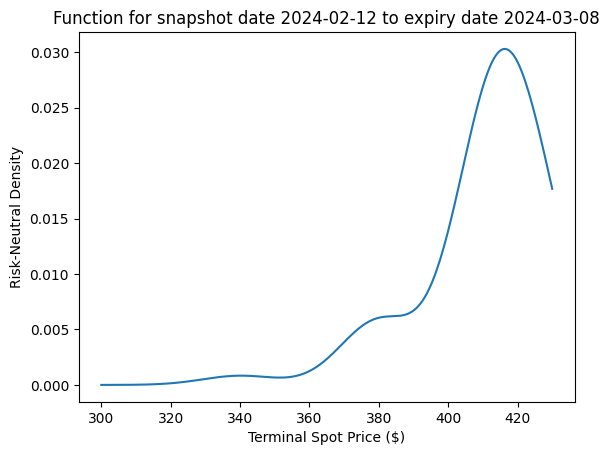

In [189]:
# random plot generation
# separate from dictionary in case multiple runs from same dictionary are required

# random selection from dictionary
key = random.choice(list(rnd_dict.keys()))
snap, exp = key
entry = rnd_dict[key]

strikes, rnds = entry['density']
plt.plot(strikes, rnds)
plt.xlabel('Terminal Spot Price ($)')
plt.ylabel('Risk-Neutral Density')
plt.title(f'Function for snapshot date {snap} to expiry date {exp}')
plt.show()

# 5. Metric Collection for reports
Cell purely generated by Claude to collect the metrics required for the associated report.

In [190]:

# =================== METRICS COLLECTION===================
# Aggregate statistics across all successfully computed RNDs

from scipy.stats import skew, kurtosis
import os

print("\n" + "="*80)
print("REPORT METRICS COLLECTION")
print("="*80)

# Overall dataset processing statistics
total_combos = len(keys)
successful_rnds = len(rnd_dict)
rejection_rate = 100 * (1 - successful_rnds / total_combos) if total_combos > 0 else 0

print(f"\nDATASET PROCESSING SUMMARY")
print(f"  Total snapshot-expiry combinations: {total_combos}")
print(f"  Successfully processed: {successful_rnds} ({100*successful_rnds/total_combos:.1f}%)")
print(f"  Rejected: {total_combos - successful_rnds} ({rejection_rate:.1f}%)")

# Grid size statistics
grid_sizes_all = [len(entry['grid']) for entry in rnd_dict.values()]
print(f"\n  Median grid size (final): {np.median(grid_sizes_all):.0f} strikes")
print(f"  Min grid size: {np.min(grid_sizes_all):.0f} strikes")
print(f"  Max grid size: {np.max(grid_sizes_all):.0f} strikes")
print(f"  Mean grid size: {np.mean(grid_sizes_all):.1f} strikes")

# DTE statistics
dtes_all = [entry['dte'] for entry in rnd_dict.values()]
print(f"\n  DTE statistics:")
print(f"    Median: {np.median(dtes_all):.0f} days")
print(f"    Range: {np.min(dtes_all):.0f} - {np.max(dtes_all):.0f} days")

# RND shape statistics
skewnesses = []
kurtoses = []
rnd_stds = []
rnd_means = []

for entry in rnd_dict.values():
    strikes_arr, rnds_arr = entry['density']
    strikes_arr = np.array(strikes_arr)
    rnds_arr = np.array(rnds_arr)
    
    # Calculate statistics
    rnd_mean = np.average(strikes_arr, weights=rnds_arr)
    rnd_var = np.average((strikes_arr - rnd_mean)**2, weights=rnds_arr)
    rnd_std = np.sqrt(rnd_var)
    
    # Skewness: third moment
    rnd_skew = np.average((strikes_arr - rnd_mean)**3, weights=rnds_arr) / (rnd_std**3)
    # Kurtosis: fourth moment (excess kurtosis = fourth moment - 3)
    rnd_kurt = np.average((strikes_arr - rnd_mean)**4, weights=rnds_arr) / (rnd_std**4) - 3
    
    skewnesses.append(rnd_skew)
    kurtoses.append(rnd_kurt)
    rnd_stds.append(rnd_std)
    rnd_means.append(rnd_mean)

print(f"\n  RND SHAPE METRICS:")
print(f"    Skewness (median): {np.median(skewnesses):.4f}")
print(f"    % negatively skewed: {100*sum([1 for s in skewnesses if s < 0])/len(skewnesses):.1f}%")
print(f"    Kurtosis (median): {np.median(kurtoses):.4f}")
print(f"    Volatility (median std dev): {np.median(rnd_stds):.2f}")

print("\n" + "="*80)

# Store metrics for later access
metrics_summary = {
    'total_combos': total_combos,
    'successful': successful_rnds,
    'rejection_rate': rejection_rate,
    'median_grid_size': np.median(grid_sizes_all),
    'median_dte': np.median(dtes_all),
    'median_skewness': np.median(skewnesses),
    'pct_neg_skew': 100*sum([1 for s in skewnesses if s < 0])/len(skewnesses),
    'median_kurtosis': np.median(kurtoses),
    'median_volatility': np.median(rnd_stds)
}

print("\nMetrics stored in 'metrics_summary' dict for report")



REPORT METRICS COLLECTION

DATASET PROCESSING SUMMARY
  Total snapshot-expiry combinations: 7112
  Successfully processed: 606 (8.5%)
  Rejected: 6506 (91.5%)

  Median grid size (final): 40 strikes
  Min grid size: 8 strikes
  Max grid size: 97 strikes
  Mean grid size: 38.4 strikes

  DTE statistics:
    Median: 17 days
    Range: 10 - 64 days

  RND SHAPE METRICS:
    Skewness (median): -0.8974
    % negatively skewed: 78.2%
    Kurtosis (median): 1.5981
    Volatility (median std dev): 12.45


Metrics stored in 'metrics_summary' dict for report


# 6. Graphical RND Examples
Four negatively skewed distributions of the same snapshot date but increasing expiration dates will be chosen as the textbook example to be shown in the report. We will choose from the first 
 $N=90$ snapshot dates.

The entire cell was generated by Claude.

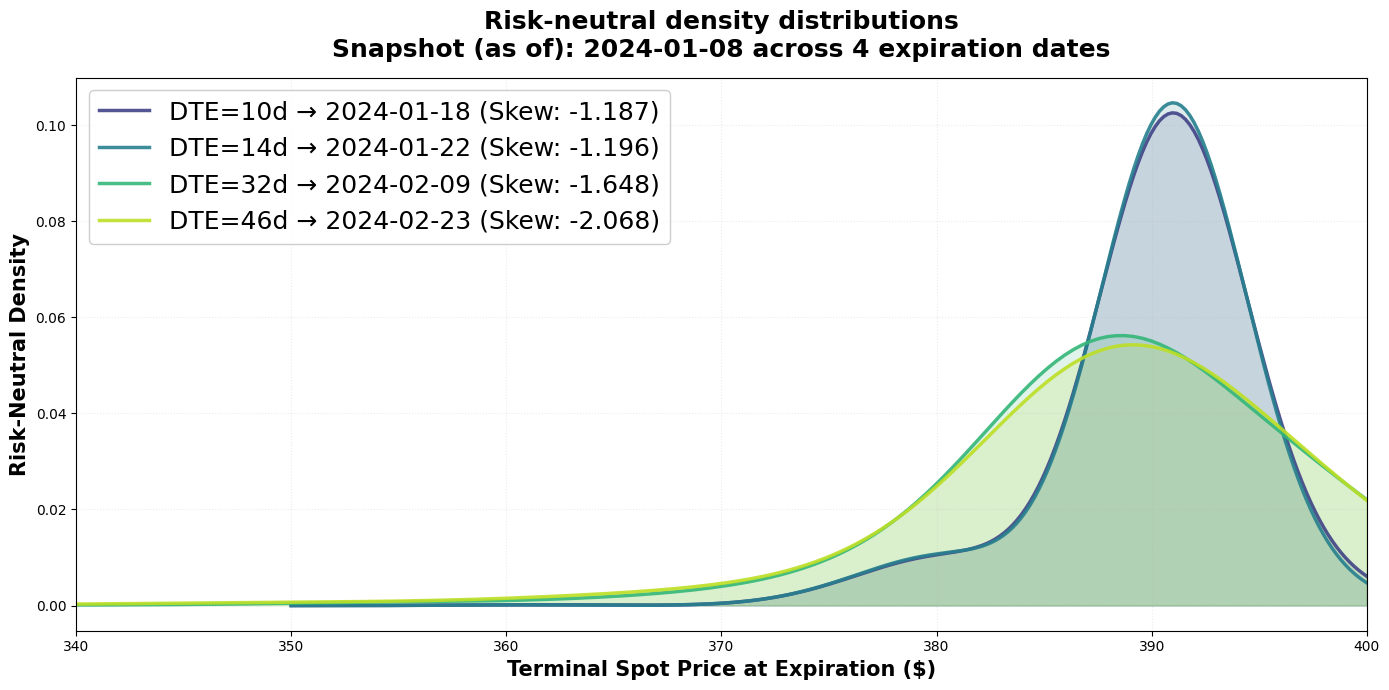

In [191]:
snap = '2024-01-08'
selections = [
    ('2024-01-18', 10),
    ('2024-01-22', 14),
    ('2024-02-09', 32),
    ('2024-02-23', 46)
]

# Use perceptually uniform colormap for progression through DTEs
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 4))
fig, ax = plt.subplots(figsize=(14, 7))

for idx, (exp_date, dte) in enumerate(selections):
    key = (snap, exp_date)
    if key not in rnd_dict:
        print(f"Warning: {key} not found in rnd_dict")
        continue
    
    entry = rnd_dict[key]
    strikes_arr = np.array(entry['density'][0])
    rnds_arr = np.array(entry['density'][1])
    
    # Calculate skewness
    rnd_mean = np.average(strikes_arr, weights=rnds_arr)
    rnd_var = np.average((strikes_arr - rnd_mean)**2, weights=rnds_arr)
    rnd_std = np.sqrt(rnd_var)
    skewness = np.average((strikes_arr - rnd_mean)**3, weights=rnds_arr) / (rnd_std**3)
    
    ax.plot(strikes_arr, rnds_arr, 
            color=colors[idx], 
            linewidth=2.5,
            alpha=0.9,
            label=f'DTE={dte}d → {exp_date} (Skew: {skewness:.3f})')
    
    ax.fill_between(strikes_arr, rnds_arr, alpha=0.15, color=colors[idx])

ax.set_xlim(340, 400)
ax.set_xlabel('Terminal Spot Price at Expiration ($)', fontsize=15, fontweight='bold')
ax.set_ylabel('Risk-Neutral Density', fontsize=15, fontweight='bold')
ax.set_title(f'Risk-neutral density distributions\n' +
             f'Snapshot (as of): {snap} across 4 expiration dates',
             fontsize=18, fontweight='bold', pad=15)
ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.8)
ax.legend(fontsize=18, loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.show()